In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('data_science_job.csv')

In [6]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [ ]:
df.describe()     # it only work on numerical data

,enrollee_id,city_development_index,experience,training_hours,target
count,19158.000000,18679.000000,19093.000000,18392.000000,19158.000000
mean,16875.358179,0.828951,9.928036,65.185787,0.249348
std,9616.292592,0.123334,6.505268,59.885626,0.432647
min,1.000000,0.448000,0.000000,1.000000,0.000000
25%,8554.250000,0.740000,4.000000,23.000000,0.000000
50%,16982.500000,0.903000,9.000000,47.000000,0.000000
75%,25169.750000,0.920000,16.000000,88.000000,0.000000
max,33380.000000,0.949000,20.000000,336.000000,1.000000


In [9]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [10]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [11]:
df.shape

(19158, 13)

In [12]:
cols=[var for var in df.columns if df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [13]:
df[cols].sample(4)

,city_development_index,enrolled_university,education_level,experience,training_hours
18961,0.910,no_enrollment,Graduate,6.0,31.0
15878,0.939,no_enrollment,Masters,20.0,130.0
1830,0.926,Full time course,Primary School,5.0,52.0
7617,0.624,no_enrollment,Graduate,14.0,40.0


In [ ]:
len(df[cols].dropna())          # non null rows

17182

In [15]:
len(df[cols].dropna())/len(df)    # percentage of non null rows

0.8968577095730244

In [16]:
new_df=df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

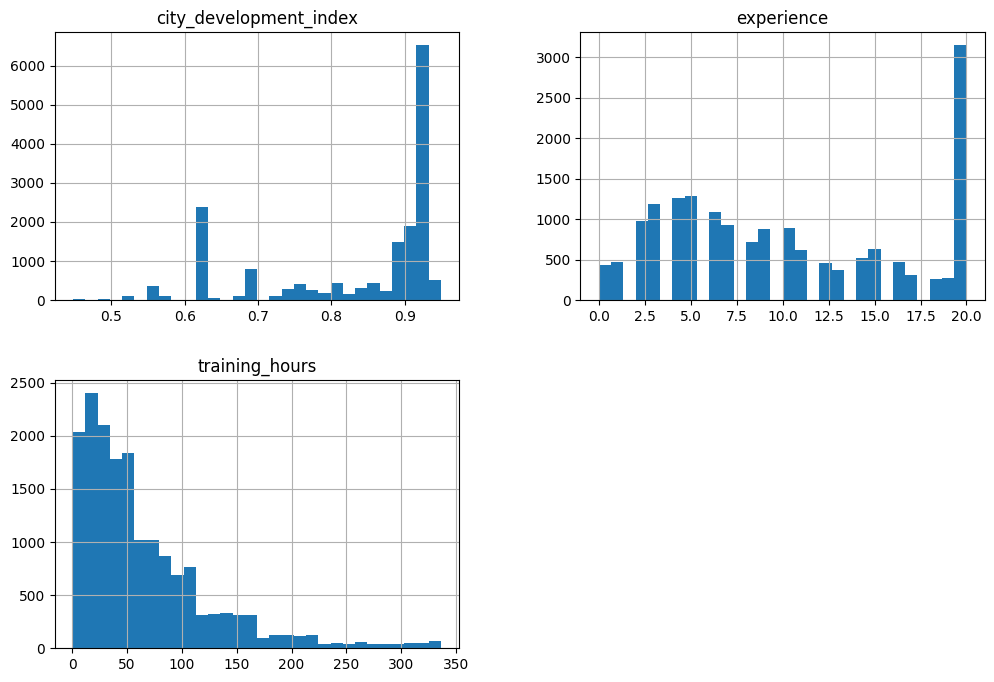

In [ ]:
new_df.hist(bins=30,figsize=(12,8))
plt.show()

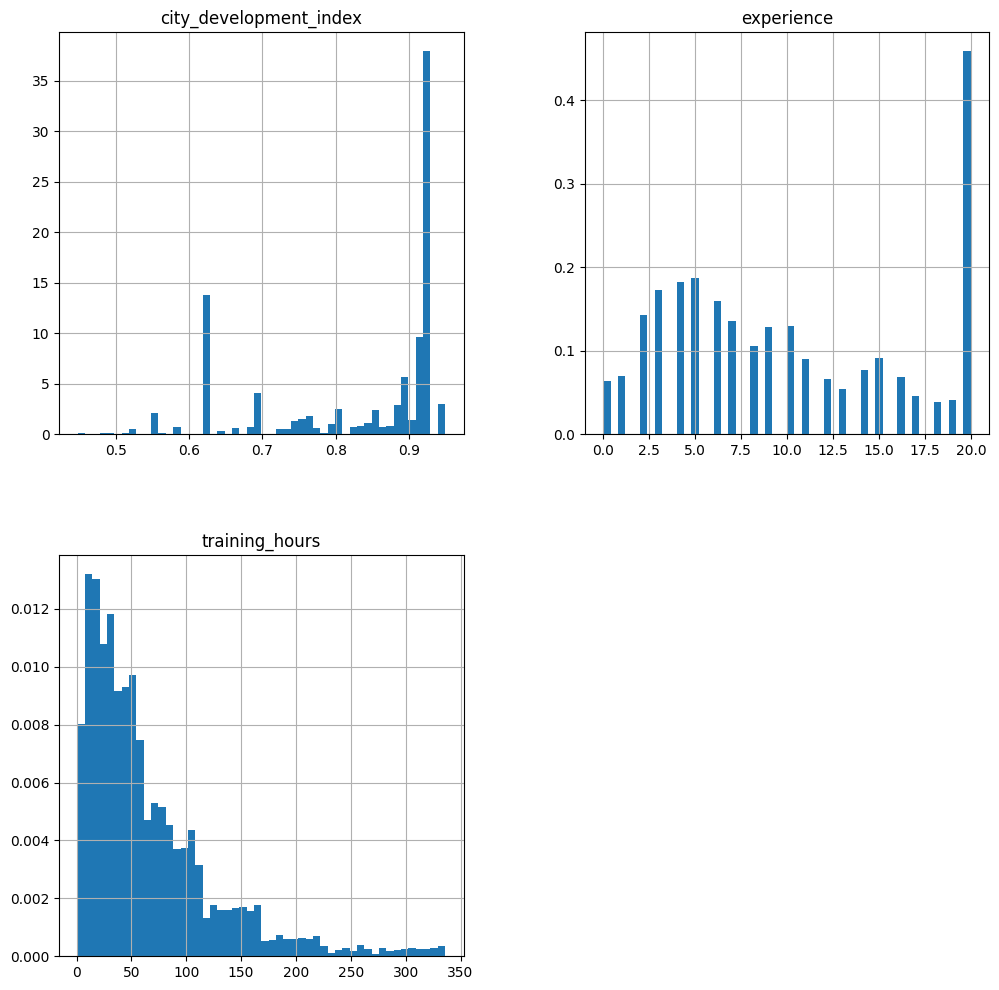

In [ ]:
new_df.hist(bins=50, density=True, figsize=(12, 12))   # density=True for probability density function
plt.show()
"""
histogram with density=True:
∑(bar height×bin width)=1

✔️ Area = 1

density=False → “How many samples?”
density=True → “How likely is this range?”
"""

<Axes: >

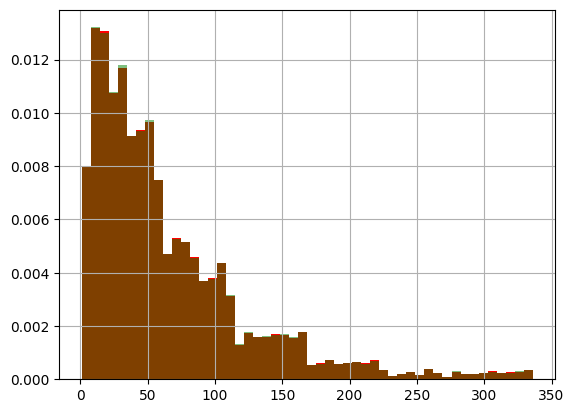

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['training_hours'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.5)

<Axes: ylabel='Density'>

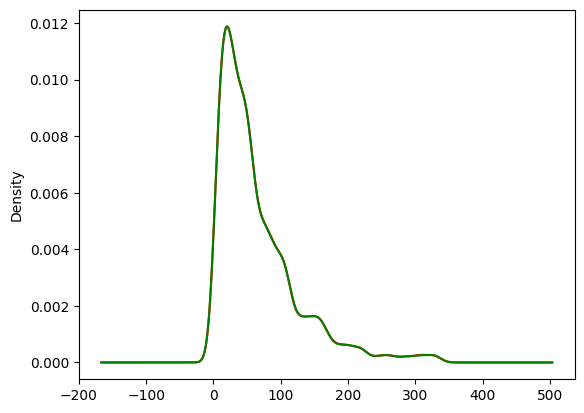

In [27]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='red')

# data after cca
new_df['training_hours'].plot.density(color='green')

<Axes: >

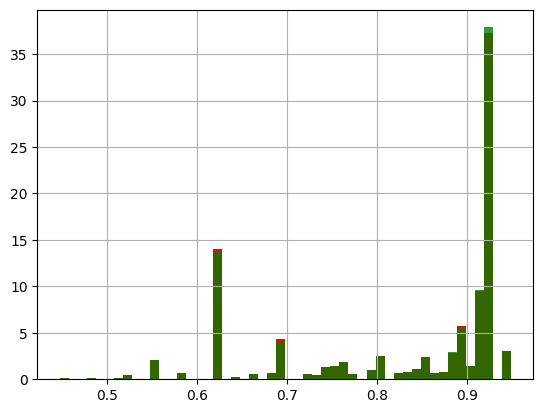

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['city_development_index'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: >

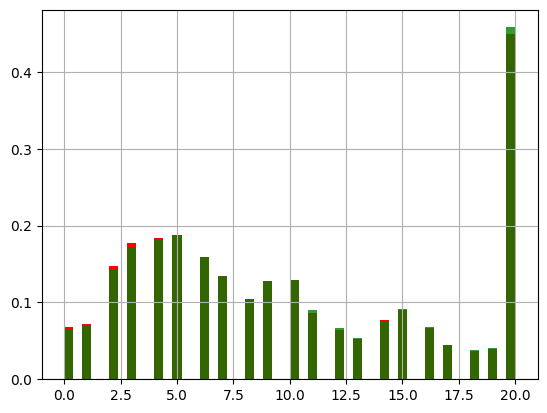

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

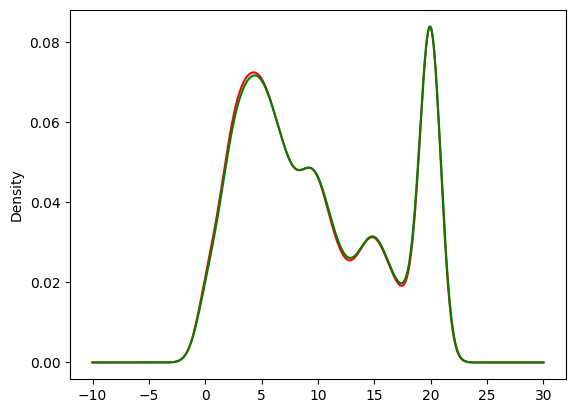

In [30]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].plot.density(color='red')

# data after cca
new_df['experience'].plot.density(color='green')

*** As we only choose those columns, where missing probablity is  (0,0.5), so that their is not big change, even after removing those rows

In [26]:
temp=pd.concat([
    df['enrolled_university'].value_counts() / len(df),
    new_df['enrolled_university'].value_counts() / len(new_df)
], axis=1
)

temp.columns = ['original', 'after_cca']
temp

,original,after_cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


0.721 → 0.735 (+1.4%)

What this means

- Rows removed by CCA were roughly random

- Distribution is mostly preserved

- CCA is safe here

📌 Small shifts (≈1–2%) are normal and acceptable.

✅ Conclusion:
CCA did not introduce serious bias.

In [ ]:
temp= pd.concat([
    df['education_level'].value_counts()/ len(df),
    new_df['education_level'].value_counts()/ len(new_df)
], axis=1)

temp.columns = ['original', 'after_cca']
temp

,original,after_cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587


: 

### Change < 2–3% → CCA OK 

### Change 5–10% → Warning 

### Change > 10% → Don’t use CCA 

- Missing values are very few (≈ < 5%)

- Data is Missing Completely At Random (MCAR)

- Dataset is large enough to lose some rows

- You want a quick baseline model

📌 Example:

    -10,000 rows → 150 rows have missing values → OK to drop